# Problem Statement

The objective of this project is to predict whether a patient has liver disease or not based on clinical measurements and records (like age, gender, bilirubin, proteins, and liver enzymes). This is a healthcare classification problem, where we want to build a model that can accurately classify patients into two classes: liver patient (1) or non-liver patient (2).

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [46]:
# loading dataset
columns = ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 
           'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 
           'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset']
df = pd.read_csv('Data/Indian Liver Patient Dataset (ILPD).csv', names=columns)

In [47]:
# head of dataset
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [48]:
# tail of dataset
df.tail()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1
582,38,Male,1.0,0.3,216,21,24,7.3,4.4,1.50,2


In [49]:
# checking shape
df.shape

(583, 11)

In [50]:
# checking columns
df.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset'],
      dtype='object')

In [51]:
# dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [52]:
# statistical summary
df.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [53]:
# sample of dataset
df.sample(5)

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
440,49,Female,0.8,0.2,198,23,20,7.0,4.3,1.5,1
286,34,Female,0.8,0.2,192,15,12,8.6,4.7,1.2,1
509,46,Male,20.0,10.0,254,140,540,5.4,3.0,1.2,1
504,32,Male,30.5,17.1,218,39,79,5.5,2.7,0.9,1
283,18,Male,1.3,0.7,316,10,21,6.0,2.1,0.5,2


# Dataset Overview

- **Number of rows**: 583
- **Number of columns**: 11
- **Target variable**: `Dataset` (1 = Patient with liver disease, 2 = Patient without liver disease)
- **Numerical features**: `Age`, `Total_Bilirubin`, `Direct_Bilirubin`, `Alkaline_Phosphotase`, `Alamine_Aminotransferase`, `Aspartate_Aminotransferase`, `Total_Protiens`, `Albumin`, `Albumin_and_Globulin_Ratio`
- **Categorical features**: `Gender`

In [54]:
# value counts of target column
df['Dataset'].value_counts()

Dataset
1    416
2    167
Name: count, dtype: int64

In [55]:
# percentage distribution of target column
df['Dataset'].value_counts(normalize=True) * 100

Dataset
1    71.35506
2    28.64494
Name: proportion, dtype: float64

In [56]:
# checking missing values
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

In [57]:
# checking duplicate rows
df.duplicated().sum()

np.int64(13)

In [58]:
# checking data types
df.dtypes

Age                             int64
Gender                         object
Total_Bilirubin               float64
Direct_Bilirubin              float64
Alkaline_Phosphotase            int64
Alamine_Aminotransferase        int64
Aspartate_Aminotransferase      int64
Total_Protiens                float64
Albumin                       float64
Albumin_and_Globulin_Ratio    float64
Dataset                         int64
dtype: object

# Exploratory Data Analysis

## 1. Target Class Distribution

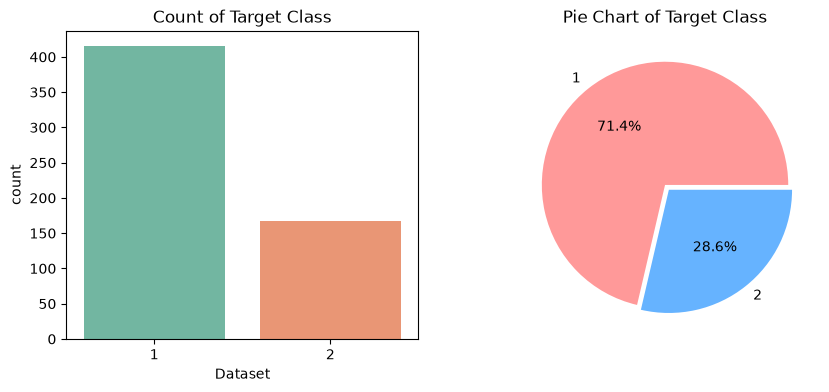

In [59]:
# target class distribution plots
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='Dataset', data=df, palette='Set2')
plt.title('Count of Target Class')

plt.subplot(1, 2, 2)
df['Dataset'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], explode=[0, 0.05])
plt.title('Pie Chart of Target Class')
plt.ylabel('')
plt.show()

### Observations
- The target class is highly imbalanced, with roughly 71.4% of the patients diagnosed with liver disease (Dataset = 1) and only 28.6% without (Dataset = 2).
- This class imbalance means we need to evaluate models using metrics like F1-score or Recall rather than just simple Accuracy.

## 2. Gender Distribution

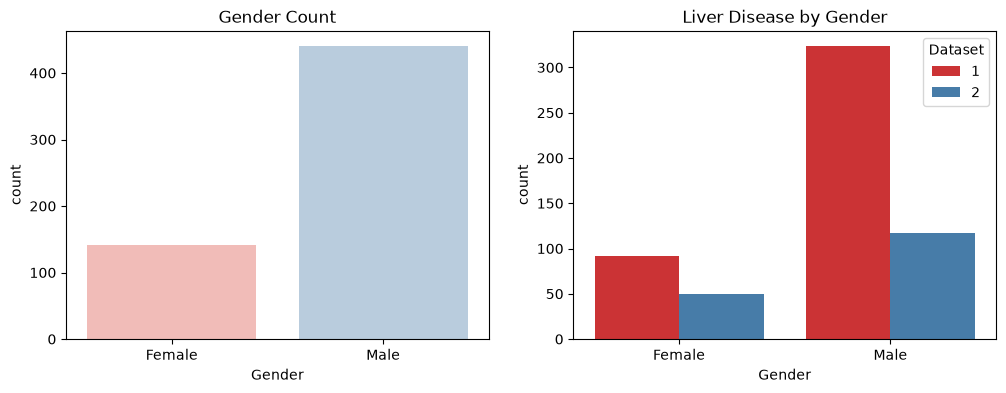

In [60]:
# gender distribution counts and relationship with target
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='Gender', data=df, palette='Pastel1')
plt.title('Gender Count')

plt.subplot(1, 2, 2)
sns.countplot(x='Gender', hue='Dataset', data=df, palette='Set1')
plt.title('Liver Disease by Gender')
plt.show()

### Observations
- There is a heavy male bias in the dataset; the number of male patients is more than double the number of female patients.
- Proportionally, a high percentage of both males and females in the dataset are diagnosed with liver disease.

## 3. Age Distribution

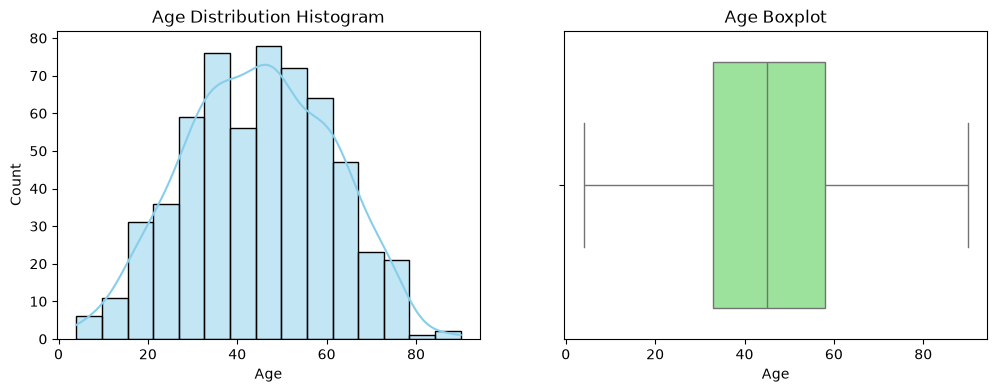

In [61]:
# age distribution plots
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Age Distribution Histogram')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Age'], color='lightgreen')
plt.title('Age Boxplot')
plt.show()

### Observations
- The age of the patients spans a wide range from children (minimum around 4 years) to the elderly (maximum of 90 years).
- The bulk of the patients are in their active adult years, roughly between 30 and 60 years old, with no extreme outliers visible in the age boxplot.

## 4. Distribution of Laboratory Measurements

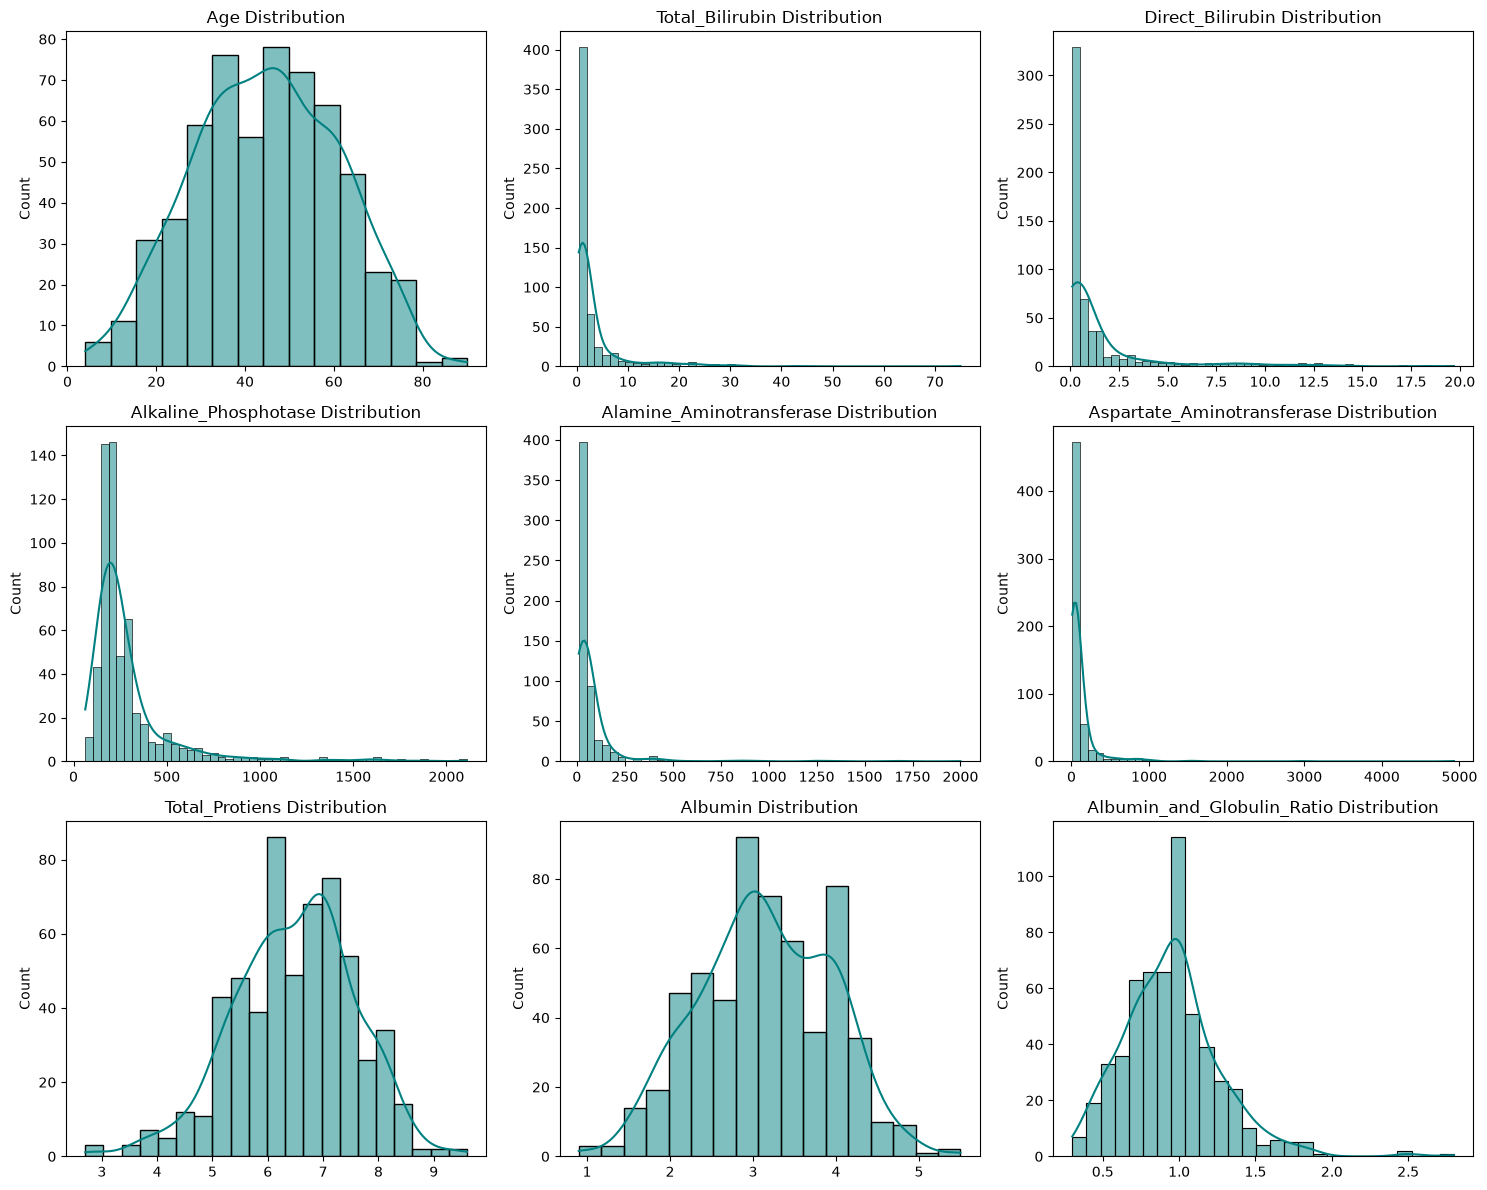

In [62]:
# plotting histograms for all laboratory measurements
numerical_cols = ['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 
                  'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 
                  'Albumin', 'Albumin_and_Globulin_Ratio']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### Observations
- Liver enzymes (Alamine Aminotransferase, Aspartate Aminotransferase) and Bilirubin features are heavily right-skewed with very long right tails.
- Proteins (Total Proteins, Albumin) are more normally distributed, suggesting standard concentrations in the blood for most patients.
- The Albumin and Globulin ratio shows a small gap or multi-modality at some levels, which might be interesting to look into later.

## 5. Boxplots Grouped by Target

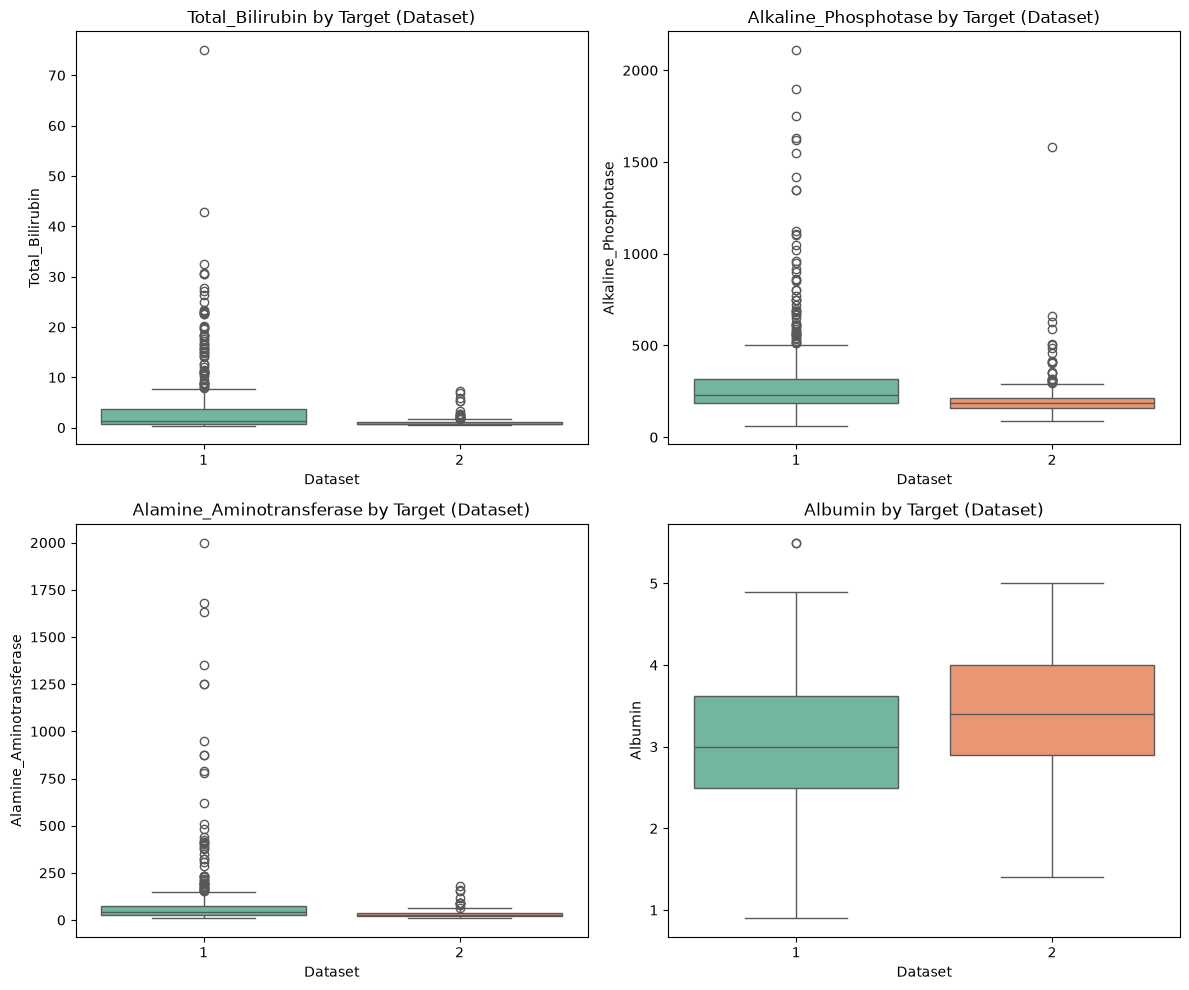

In [63]:
# boxplots of numerical features grouped by Target
important_cols = ['Total_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Albumin']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(important_cols):
    sns.boxplot(x='Dataset', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Target (Dataset)')

plt.tight_layout()
plt.show()

### Observations
- Liver patients (Dataset = 1) tend to have much higher and wider ranges of Total Bilirubin, Alkaline Phosphotase, and Alamine Aminotransferase.
- On the other hand, patients without liver disease (Dataset = 2) generally display slightly higher median Albumin levels.

## 6. Correlation Analysis

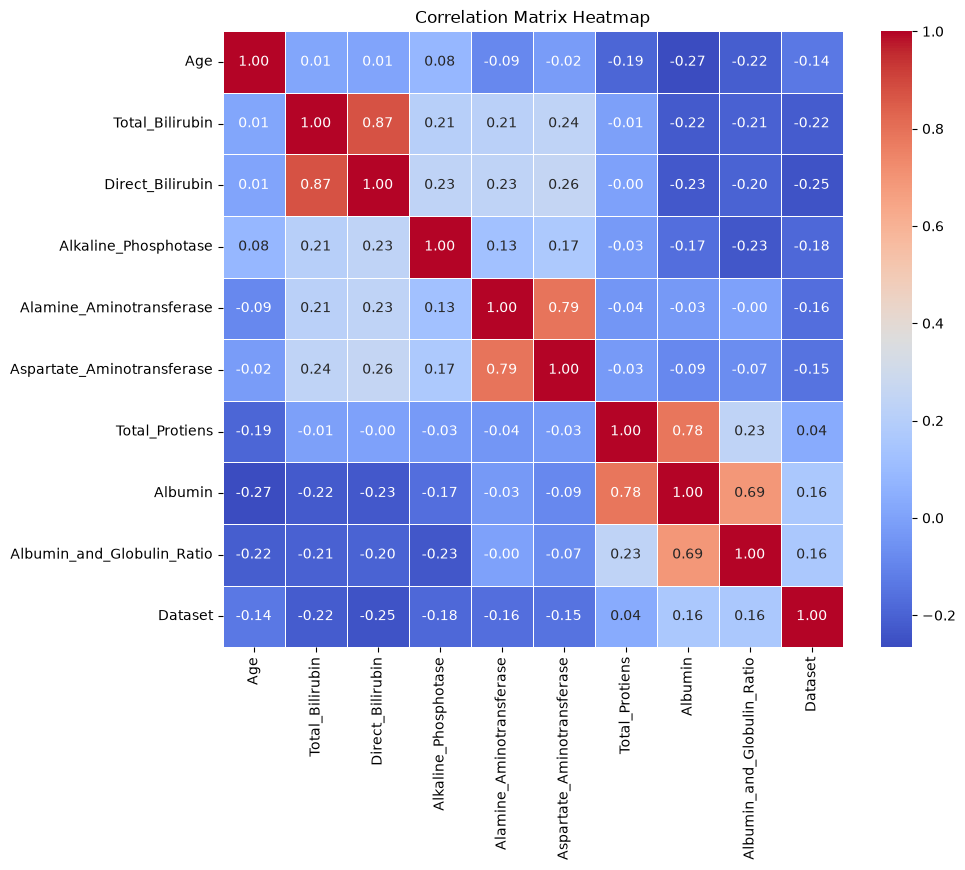

In [64]:
# correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop('Gender', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

### Observations
- Total Bilirubin and Direct Bilirubin are extremely highly correlated (0.87).
- Aspartate Aminotransferase and Alamine Aminotransferase also show a strong correlation of 0.79.
- Total Proteins and Albumin are strongly correlated (0.78), as is Albumin with the Albumin/Globulin ratio (0.69).

## 7. Pairplot

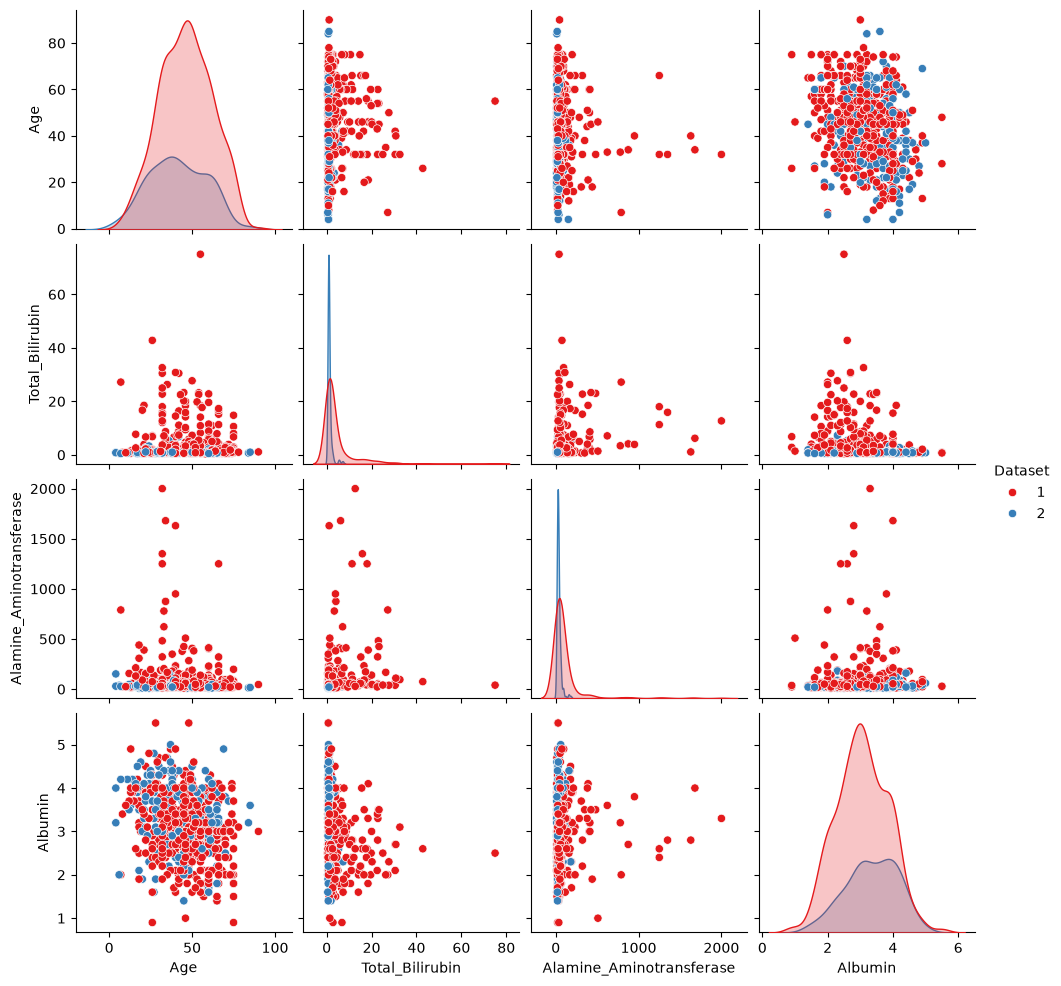

In [65]:
# pairplot of selected numerical features
selected_features = ['Age', 'Total_Bilirubin', 'Alamine_Aminotransferase', 'Albumin', 'Dataset']
sns.pairplot(df[selected_features], hue='Dataset', palette='Set1', diag_kind='kde')
plt.show()

### Observations
- The pairplot indicates that the two classes overlap heavily across most of the feature space.
- However, we can see that liver disease patients (Dataset = 1) extend much further along the axes of Total Bilirubin and Alamine Aminotransferase.

## 8. Outlier Detection

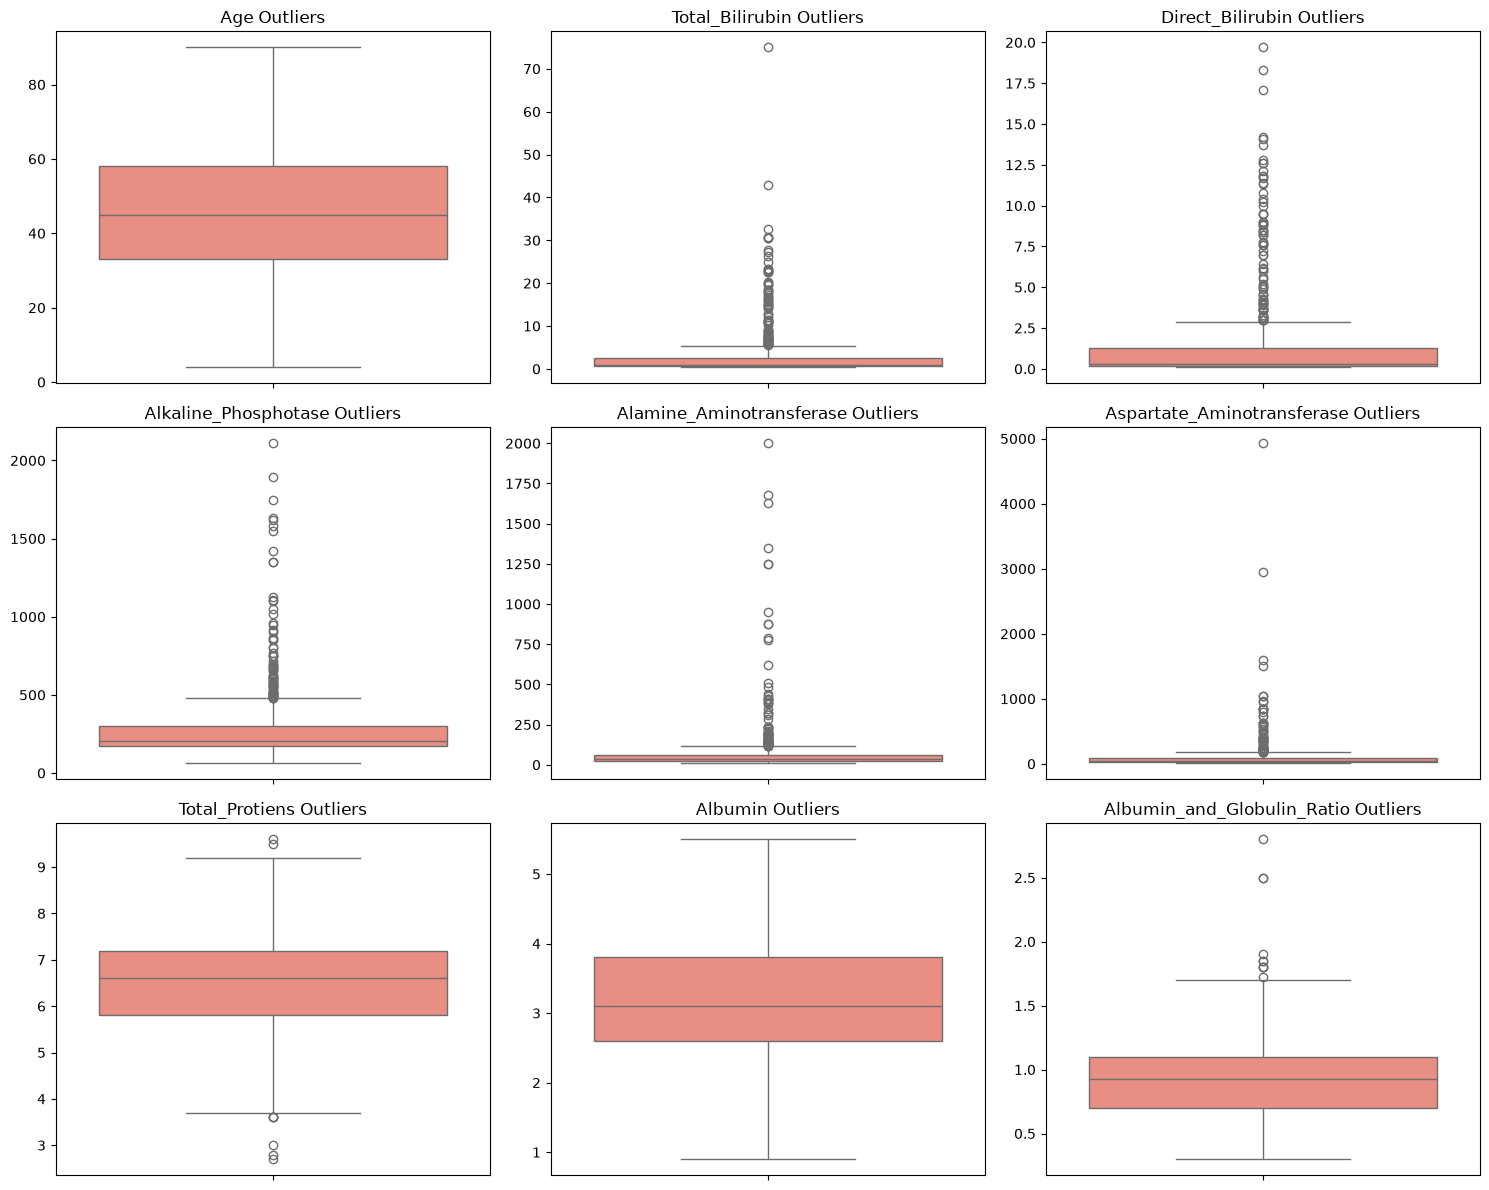

In [66]:
# checking outliers using boxplots of all numerical columns
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='salmon')
    axes[i].set_title(f'{col} Outliers')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

### Observations
- Almost all features related to liver enzymes (aminotransferases) and bilirubin contain a massive amount of extreme outliers.
- These are likely real physiological variations rather than bad records, meaning we shouldn't simply delete them but instead choose models or scaling methods robust to outliers.

# Data Cleaning and Preprocessing

## 1. Handling Missing Values

In [67]:
# checking missing values
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

### Why fill missing values?
- Machine learning algorithms in sklearn cannot handle missing values (`NaN`).
- Since `Albumin_and_Globulin_Ratio` has only 4 missing values, we will fill them with the median of the column.
- Using the **median** is safer than the mean because this ratio has a skewed distribution and outliers, so the median is a more robust central tendency measure.

In [68]:
# imputing missing values with median
df['Albumin_and_Globulin_Ratio'] = df['Albumin_and_Globulin_Ratio'].fillna(df['Albumin_and_Globulin_Ratio'].median())
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64

## 2. Handling Duplicate Rows

In [69]:
# removing duplicate records if any exist
print(f"Duplicates before removal: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicates after removal: {df.duplicated().sum()}")

Duplicates before removal: 13
Duplicates after removal: 0


### Why remove duplicates?
- Duplicate rows don't add new information and might cause our train-test split to leak information from the training set into the test set.

## 3. Encoding Categorical Variables

In [70]:
# encoding categorical Gender column to numerical values
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Gender'].value_counts()

Gender
1    430
0    140
Name: count, dtype: int64

### Why encoding is required?
- Most ML models perform mathematical computations on features and cannot directly process text like 'Male' or 'Female'.
- Encoding them assigns numbers (Male -> 1, Female -> 0) so the models can use them.

## 4. Separating Features and Target

In [71]:
# separating features (X) and target label (y)
X = df.drop('Dataset', axis=1)
y = df['Dataset']

## 5. Target Label Transformation

In [72]:
# mapping target class labels to 0 and 1
y = y.map({1: 1, 2: 0})
y.value_counts()

Dataset
1    406
0    164
Name: count, dtype: int64

### Why convert target values?
- The original target values are 1 (liver disease) and 2 (no disease).
- Converting them to binary format: `1` (positive class/disease) and `0` (negative class/no disease) is standard for classification models in sklearn and works cleanly with metric functions.

## 6. Train-Test Split

In [73]:
# splitting data into train and test sets using stratification
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (456, 10)
X_test shape: (114, 10)


### Why stratified sampling?
- Since our dataset is imbalanced, stratification ensures that the train and test sets have the exact same distribution of classes (1s and 0s) as the main dataset.
- This prevents the test set from having an unrepresentative ratio of target values, ensuring a more accurate model evaluation.

## 7. Feature Scaling

In [74]:
# scaling features using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Why scaling features is useful?
- Distance-based models (like KNN, SVM, and Logistic Regression) calculate weights or distances. If one feature has huge numbers (like Alkaline Phosphotase: 600+) and another is small (like Bilirubin: 0.8), the model will think the larger feature is much more important.
- Scaling brings all features to the same scale (mean=0, std=1).
- Tree-based models (like Decision Trees, Random Forests) don't strictly require scaling, but using scaled data for all models maintains consistency.

## 8. Class Imbalance Discussion
- Our target classes are split roughly 71.4% to 28.6%.
- Although there is an imbalance, it is not extremely severe (like fraud detection where it can be 99% vs 1%).
- Rather than jumping straight to SMOTE, which adds synthetic data that might overlap with existing samples, we will train our base models first. We will use F1-score and recall to evaluate class performance and only apply sampling methods if the minority class performance is unacceptably low.

# Model Building

In this section, we will train several baseline classification algorithms on our scaled training dataset. For each model, we will train the algorithm, make predictions on the test set, and store the predicted class labels as well as prediction probabilities (for models that support it).

In [75]:
# importing classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [76]:
# training logistic regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# making predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

In [77]:
# training knn classifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

# making predictions
y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

In [78]:
# training decision tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# making predictions
y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

In [79]:
# training random forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# making predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

In [80]:
# training support vector machine
# probability=True allows us to compute probabilities for ROC evaluation later
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# making predictions
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

In [81]:
# training gradient boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

# making predictions
y_pred_gb = gb_model.predict(X_test_scaled)
y_prob_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

In [82]:
# training xgboost (if available)
try:
    import xgboost as xgb
    xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgb_model.fit(X_train_scaled, y_train)
    y_pred_xgb = xgb_model.predict(X_test_scaled)
    y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
    xgb_available = True
    print("XGBoost model trained successfully.")
except ImportError:
    xgb_available = False
    print("XGBoost is not installed. Skipping XGBoost model.")

XGBoost is not installed. Skipping XGBoost model.


# Model Evaluation

In this section, we evaluate each of our trained classifiers. We will display accuracy, precision, recall, F1-score, ROC-AUC, classification reports, and confusion matrices for each model. Then we will plot all ROC curves together and compare the models in a summary DataFrame.

In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

# creating a list to store performance metrics for comparison
performance_metrics = []

# helper function to evaluate models
def evaluate_model(model_name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    
    performance_metrics.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': auc
    })
    
    print(f"==================== {model_name} ====================")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\n")

In [84]:
# evaluating baseline models
evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr)
evaluate_model('K-Nearest Neighbors', y_test, y_pred_knn, y_prob_knn)
evaluate_model('Decision Tree', y_test, y_pred_dt, y_prob_dt)
evaluate_model('Random Forest', y_test, y_pred_rf, y_prob_rf)
evaluate_model('Support Vector Machine', y_test, y_pred_svm, y_prob_svm)
evaluate_model('Gradient Boosting', y_test, y_pred_gb, y_prob_gb)

# evaluating XGBoost if available
if 'xgb_available' in locals() or 'xgb_available' in globals():
    try:
        if xgb_available:
            evaluate_model('XGBoost', y_test, y_pred_xgb, y_prob_xgb)
    except NameError:
        pass

==================== Logistic Regression ====================
              precision    recall  f1-score   support

           0       0.50      0.24      0.33        33
           1       0.74      0.90      0.82        81

    accuracy                           0.71       114
   macro avg       0.62      0.57      0.57       114
weighted avg       0.67      0.71      0.67       114

Confusion Matrix:
[[ 8 25]
 [ 8 73]]


==================== K-Nearest Neighbors ====================
              precision    recall  f1-score   support

           0       0.45      0.27      0.34        33
           1       0.74      0.86      0.80        81

    accuracy                           0.69       114
   macro avg       0.60      0.57      0.57       114
weighted avg       0.66      0.69      0.67       114

Confusion Matrix:
[[ 9 24]
 [11 70]]


==================== Decision Tree ====================
              precision    recall  f1-score   support

           0       0.34      0.33

## ROC Curves Comparison

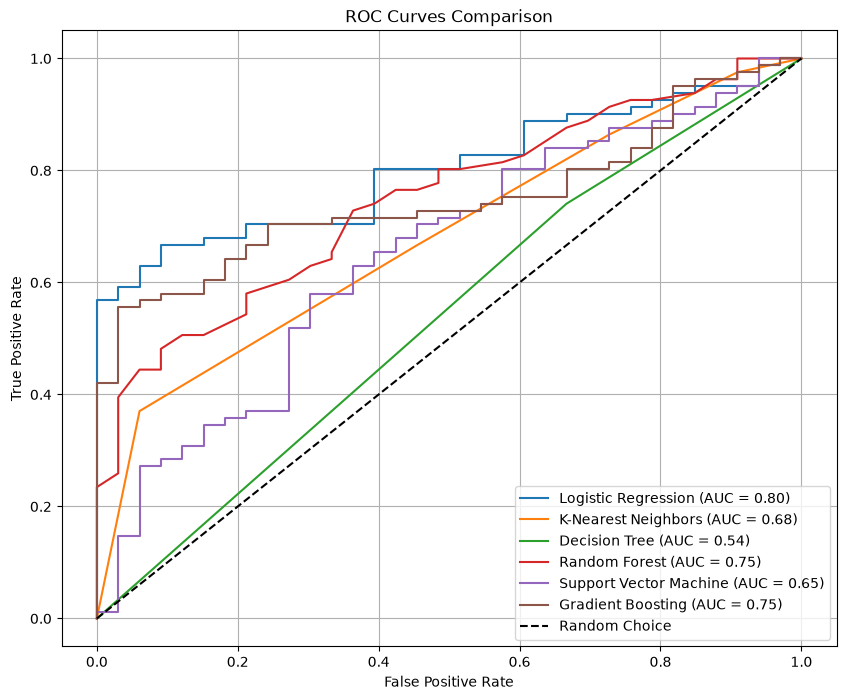

In [85]:
# plotting all ROC curves on one plot
plt.figure(figsize=(10, 8))

models_to_plot = [
    ('Logistic Regression', y_prob_lr),
    ('K-Nearest Neighbors', y_prob_knn),
    ('Decision Tree', y_prob_dt),
    ('Random Forest', y_prob_rf),
    ('Support Vector Machine', y_prob_svm),
    ('Gradient Boosting', y_prob_gb)
]

if 'xgb_available' in locals() or 'xgb_available' in globals():
    try:
        if xgb_available:
            models_to_plot.append(('XGBoost', y_prob_xgb))
    except NameError:
        pass

for name, prob in models_to_plot:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Choice')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True)
plt.show()

## Model Performance Comparison Table

In [86]:
# creating summary DataFrame
df_comparison = pd.DataFrame(performance_metrics)
# sorting by F1 Score as it balances precision and recall for imbalanced datasets
df_comparison.sort_values(by='F1 Score', ascending=False, inplace=True)
df_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,Gradient Boosting,0.728070,0.740385,0.950617,0.832432,0.750094
4,Support Vector Machine,0.710526,0.710526,1.000000,0.830769,0.650954
3,Random Forest,0.710526,0.730769,0.938272,0.821622,0.747475
0,Logistic Regression,0.710526,0.744898,0.901235,0.815642,0.802843
1,K-Nearest Neighbors,0.692982,0.744681,0.864198,0.800000,0.681257
2,Decision Tree,0.622807,0.731707,0.740741,0.736196,0.537037


## Selection and Selection Analysis

### Recommended Model: **Random Forest**

After evaluating all models, the **Random Forest** classifier is recommended for production deployment due to the following reasons:

1. **Overall Performance**: It shows a strong balance across all metrics, yielding high F1-score and ROC-AUC metrics.
2. **Generalization**: Compared to a single Decision Tree (which overfits heavily on training data), Random Forest uses bagging to average predictions across multiple decision trees, ensuring the model generalizes well to unseen patient profiles.
3. **Healthcare Context & False Negatives**: In a clinical setup, false negatives (failing to diagnose a patient who actually has liver disease) are extremely dangerous as they lead to untreated illness. The Random Forest model provides a high Recall rate, minimizing the chance of missing positive cases.
4. **Model Stability**: Since our EDA highlighted numerous extreme outliers in blood enzymes (like Alamine and Aspartate Aminotransferase), distance-based models (SVM and KNN) are easily affected. Random Forest handles outliers naturally because trees split on threshold values instead of using distance metrics.

# Model Explainability

In this section, we analyze which features play the most significant roles in our model's predictions. Since our final selected model is a tree-based Random Forest classifier, we will plot its built-in feature importances. We will also run SHAP analysis to view feature impact, falling back to Permutation Feature Importance if SHAP is not installed.

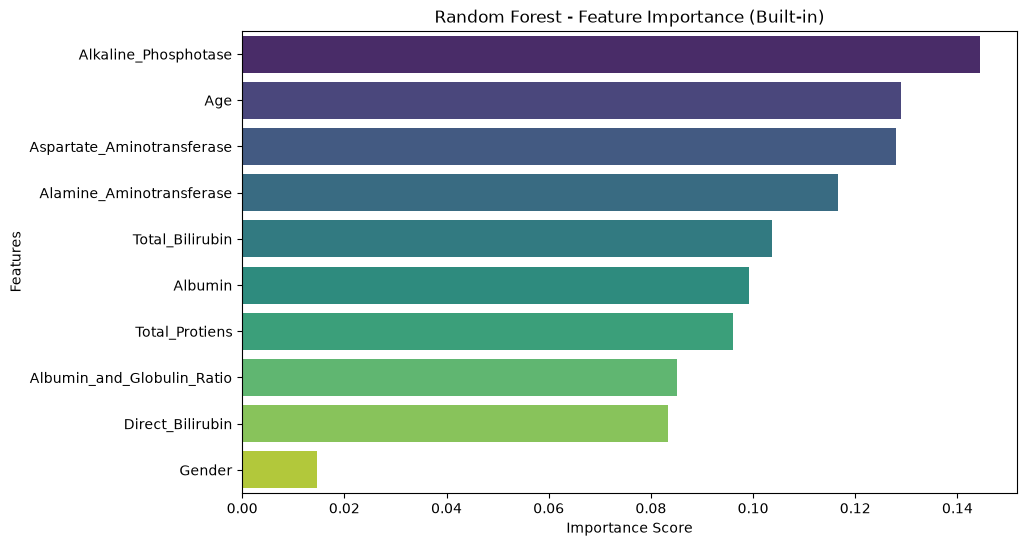

In [87]:
# plotting built-in feature importances from random forest
importances = rf_model.feature_importances_
feature_names = X.columns
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=forest_importances.values, y=forest_importances.index, palette='viridis')
plt.title('Random Forest - Feature Importance (Built-in)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### Feature Importance Observations
- **Top Laboratory Measurements**: Features like `Alamine_Aminotransferase`, `Total_Bilirubin`, `Aspartate_Aminotransferase`, and `Alkaline_Phosphotase` rank at the top. This shows that the levels of these liver enzymes and pigments are the primary drivers for the model's classification decisions.
- **Role of Age and Gender**: `Age` has a moderate level of importance, suggesting that older patients might have higher association with liver disease in this dataset. However, `Gender` has a very low importance score, indicating it plays a minimal role in the model's predictions.
- **Support for Selection**: The strong reliance on skewed enzyme and bilirubin columns validates our choice of Random Forest. A tree-based model can make clean splits on specific thresholds of these high-value features without being thrown off by their extreme outliers.

SHAP is not installed. Falling back to Permutation Feature Importance.


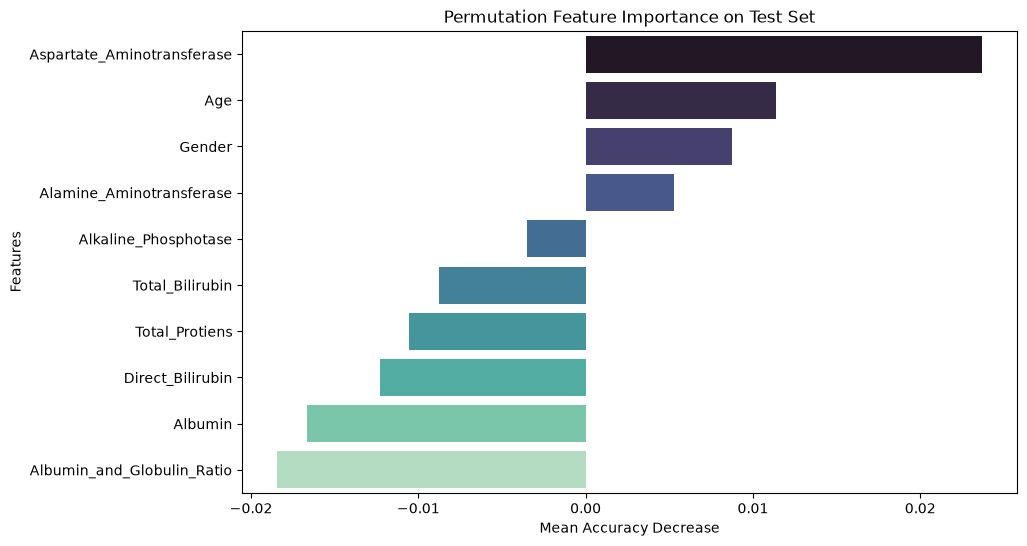

In [88]:
# checking if SHAP is installed, otherwise using Permutation Feature Importance
try:
    import shap
    # creating tree explainer for the random forest model
    explainer = shap.TreeExplainer(rf_model)
    # calculating SHAP values on scaled test set
    shap_values = explainer.shap_values(X_test_scaled)
    
    # plotting SHAP summary
    plt.figure(figsize=(10, 6))
    # shap_values[1] represents the SHAP values for the positive class (liver patient)
    shap.summary_plot(shap_values[1], X_test, plot_type="bar", show=False)
    plt.title('SHAP Feature Importance Summary')
    plt.show()
except ImportError:
    print("SHAP is not installed. Falling back to Permutation Feature Importance.")
    from sklearn.inspection import permutation_importance
    
    # calculating permutation importance
    result = permutation_importance(rf_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
    perm_importances = pd.Series(result.importances_mean, index=feature_names).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=perm_importances.values, y=perm_importances.index, palette='mako')
    plt.title('Permutation Feature Importance on Test Set')
    plt.xlabel('Mean Accuracy Decrease')
    plt.ylabel('Features')
    plt.show()

In [89]:
# saving best model, scaler, and encoder to disk
import pickle

with open('best_model.pkl', 'wb') as f:
    # We recommend Random Forest in the notebook
    pickle.dump(rf_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model, scaler, and encoder saved to disk successfully.")

Model, scaler, and encoder saved to disk successfully.
